In [1]:
import os
import copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import scipy 

from dekef.base_density import *

import seaborn as sns
from IPython.display import Markdown as md

from matplotlib import ticker, cm

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from matplotlib.patches import Ellipse
from matplotlib.patches import Rectangle

In [2]:
df = np.load('../data/geyser.npy').astype(np.float64)
waiting1 = df[:, 0].reshape(-1, 1)
waiting2 = waiting1[waiting1 != 108.0]
contam_data = 108.

In [3]:
info_coord = (0.03, 0.8)
info_coord1 = (0.03, 0.97)
info_coord2 = (0.03, 0.87)

In [4]:
label_fontsize = 25
info_fontsize = 28
tick_fontsize = 20
legend_fontsize = 30
linewidth = 4.0

In [5]:
bw = 5.0
kernel_type = 'gaussian_poly2'
xlimit = (1., 210.)
plot_pts_cnt = 3000
base_density = BasedenGamma(waiting1, 36., 2.)

In [ ]:
seed_no = 1
mlpen_folder_t = (f'data/data=geyser-waiting-PenML-bw={bw}-kernel={kernel_type}-' + 
                  f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
                  f'grid_points=1-181-1-seed={seed_no}-with108=True')

smpen_folder_t = (f'data/data=geyser-waiting-PenSM-FinKEF-bw={bw}-kernel={kernel_type}-' + 
                  f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
                  f'grid_points=1-181-1-with108=True')

mlpen_folder_f = (f'data/data=geyser-waiting-PenML-bw={bw}-kernel={kernel_type}-' + 
                  f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
                  f'grid_points=1-181-1-seed={seed_no}-with108=False')

smpen_folder_f = (f'data/data=geyser-waiting-PenSM-FinKEF-bw={bw}-kernel={kernel_type}-' + 
                  f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
                  f'grid_points=1-181-1-with108=False')

smes_folder_t = (f'data/data=geyser-waiting-EarlyStoppingSM-FinKEF-bw={bw}-kernel={kernel_type}-' + 
                 f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
                 f'grid_points=1-181-1-with108=True')

smes_folder_f = (f'data/data=geyser-waiting-EarlyStoppingSM-FinKEF-bw={bw}-kernel={kernel_type}-' + 
                 f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
                 f'grid_points=1-181-1-with108=False')

In [ ]:
mlpen_list = [-np.inf, -6., 1.][::-1]
smpen_list = [-12., -7., -2.][::-1]
smes_list = [50000, 150, 1][::-1]

In [ ]:
den_plot_xlim = (24., 120.) 
den_plot_ylim = (-0.001, 0.0505)
logden_plot_xlim = den_plot_xlim

sm_logpen = -8.

info_coord = (0.02, 0.98)
horizontalalignment, verticalalignment = 'left', 'top'

label_fontsize = 35
info_fontsize = 40
tick_fontsize = 30
legend_fontsize = 25
linewidth = 6.0
x_label = r'waiting'
y_label = r'density'

nrows = 3
ncols = 7

fig = plt.figure(figsize=(56, 27))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols, width_ratios = [1, 1, 1, 0.01, 1, 1, 1])

xticks = [50, 75, 100]

color1 = 'tab:red'
color2 = 'tab:blue'
color3 = 'tab:brown'

new_data = np.load(smpen_folder_t + f'/new_data.npy')

# ----------------------------------------------------------------------------------------
for i in range(len(mlpen_list)): 
    
    ax1 = fig.add_subplot(gs[0, i])
    contam_den = np.load(mlpen_folder_t + f'/logpenparam={mlpen_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color1)

    sns.rugplot(pd.Series(waiting1.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    plt.hist(waiting1, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.002, 
                                         color = 'indigo', fill = False, linewidth = 7.0)))
    
    ax1.set_xticks([])
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])

    if i == 0: 
        info = r"$\lambda=${ll}".format(ll = 0)
    else: 
        info = r"$\lambda=$exp({ll})".format(ll = mlpen_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

for i in range(len(mlpen_list)): 
    
    ax1 = fig.add_subplot(gs[0, i + 4])
    contam_den = np.load(mlpen_folder_f + f'/logpenparam={mlpen_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color1)

    sns.rugplot(pd.Series(waiting2.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    plt.hist(waiting2, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
#     ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
#                                          color = 'indigo', fill = False, linewidth = 7.0)))
    
    ax1.set_xticks([])
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
#     if i == 0: 
#         ax1.set_ylabel(y_label, fontsize = label_fontsize)
#     else: 
    ax1.set_yticks([])

    if i == 0: 
        info = r"$\lambda=${ll}".format(ll = 0)
    else: 
        info = r"$\lambda=$exp({ll})".format(ll = mlpen_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

# ----------------------------------------------------------------------------------------
for i in range(len(smpen_list)): 
    
    ax1 = fig.add_subplot(gs[1, i])
    contam_den = np.load(smpen_folder_t + f'/logpenparam={smpen_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color2)

    sns.rugplot(pd.Series(waiting1.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    plt.hist(waiting1, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.002, 
                                         color = 'indigo', fill = False, linewidth = 7.0)))
    
    ax1.set_xticks([])
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])

    info = r"$\rho=$exp({ll})".format(ll = smpen_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

    
for i in range(len(smpen_list)): 
    
    ax1 = fig.add_subplot(gs[1, 4 + i])
    contam_den = np.load(smpen_folder_f + f'/logpenparam={smpen_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color2)

    sns.rugplot(pd.Series(waiting2.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    plt.hist(waiting2, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    # ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
    #                                      color = 'indigo', fill = False, linewidth = 7.0)))
    
    ax1.set_xlabel(x_label, fontsize = label_fontsize)
    ax1.set_yticks([])

    info = r"$\rho=$exp({ll})".format(ll = smpen_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

# ----------------------------------------------------------------------------------------
for i in range(len(smes_list)): 
    
    ax1 = fig.add_subplot(gs[2, i])
    contam_den = np.load(smes_folder_t + f'/iter_num={smes_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color3)

    sns.rugplot(pd.Series(waiting1.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    plt.hist(waiting1, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.002, 
                                         color = 'indigo', fill = False, linewidth = 7.0)))
    
    ax1.set_xlabel(x_label, fontsize = label_fontsize)
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])

    info = r"$t=${ll}".format(ll = smes_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

    
for i in range(len(smes_list)): 
    
    ax1 = fig.add_subplot(gs[2, 4 + i])
    contam_den = np.load(smes_folder_f + f'/iter_num={smes_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color3)

    sns.rugplot(pd.Series(waiting2.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    plt.hist(waiting2, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    # ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
    #                                      color = 'indigo', fill = False, linewidth = 7.0)))
    
    ax1.set_xlabel(x_label, fontsize = label_fontsize)
    ax1.set_yticks([])

    info = r"$t=${ll}".format(ll = smes_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

ax00 = fig.add_subplot(gs[0, 3])
rect00 = Rectangle((-1, -1), 2, 2, linewidth = 1, edgecolor = 'k', facecolor = 'k')
ax00.add_patch(rect00)
ax00.set_xlim(-1, 1)
ax00.set_ylim(-1, 1)
ax00.set_xticks([])
ax00.set_yticks([])
# plt.style.use('dark_background')

ax11 = fig.add_subplot(gs[1, 3])
rect11 = Rectangle((-1, -1), 2, 2, linewidth = 1, edgecolor = 'k', facecolor = 'k')
ax11.add_patch(rect11)
ax11.set_xlim(-1, 1)
ax11.set_ylim(-1, 1)
ax11.set_xticks([])
ax11.set_yticks([])

ax22 = fig.add_subplot(gs[2, 3])
rect22 = Rectangle((-1, -1), 2, 2, linewidth = 1, edgecolor = 'k', facecolor = 'k')
ax22.add_patch(rect22)
ax22.set_xlim(-1, 1)
ax22.set_ylim(-1, 1)
ax22.set_xticks([])
ax22.set_yticks([])

plt.tight_layout()

plt.savefig(f'plots/waiting-ML-vs-SM-density-estimates-baseden=Gamma-26-3-gridpoint=1-181-1-with108-brief.pdf', 
            bbox_inches = 'tight')
plt.show()


In [7]:
smpen_folder_t = (f'../data/data=geyser-waiting-PenSM-FinKEF-bw={bw}-kernel={kernel_type}-' + 
                  f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
                  f'grid_points=1-202-1-with108=True')

smpen_folder_f = (f'../data/data=geyser-waiting-PenSM-FinKEF-bw={bw}-kernel={kernel_type}-' + 
                  f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
                  f'grid_points=1-202-1-with108=False')

smpen_list = [-12., -10., -9., -7., -5., -2.][::-1]

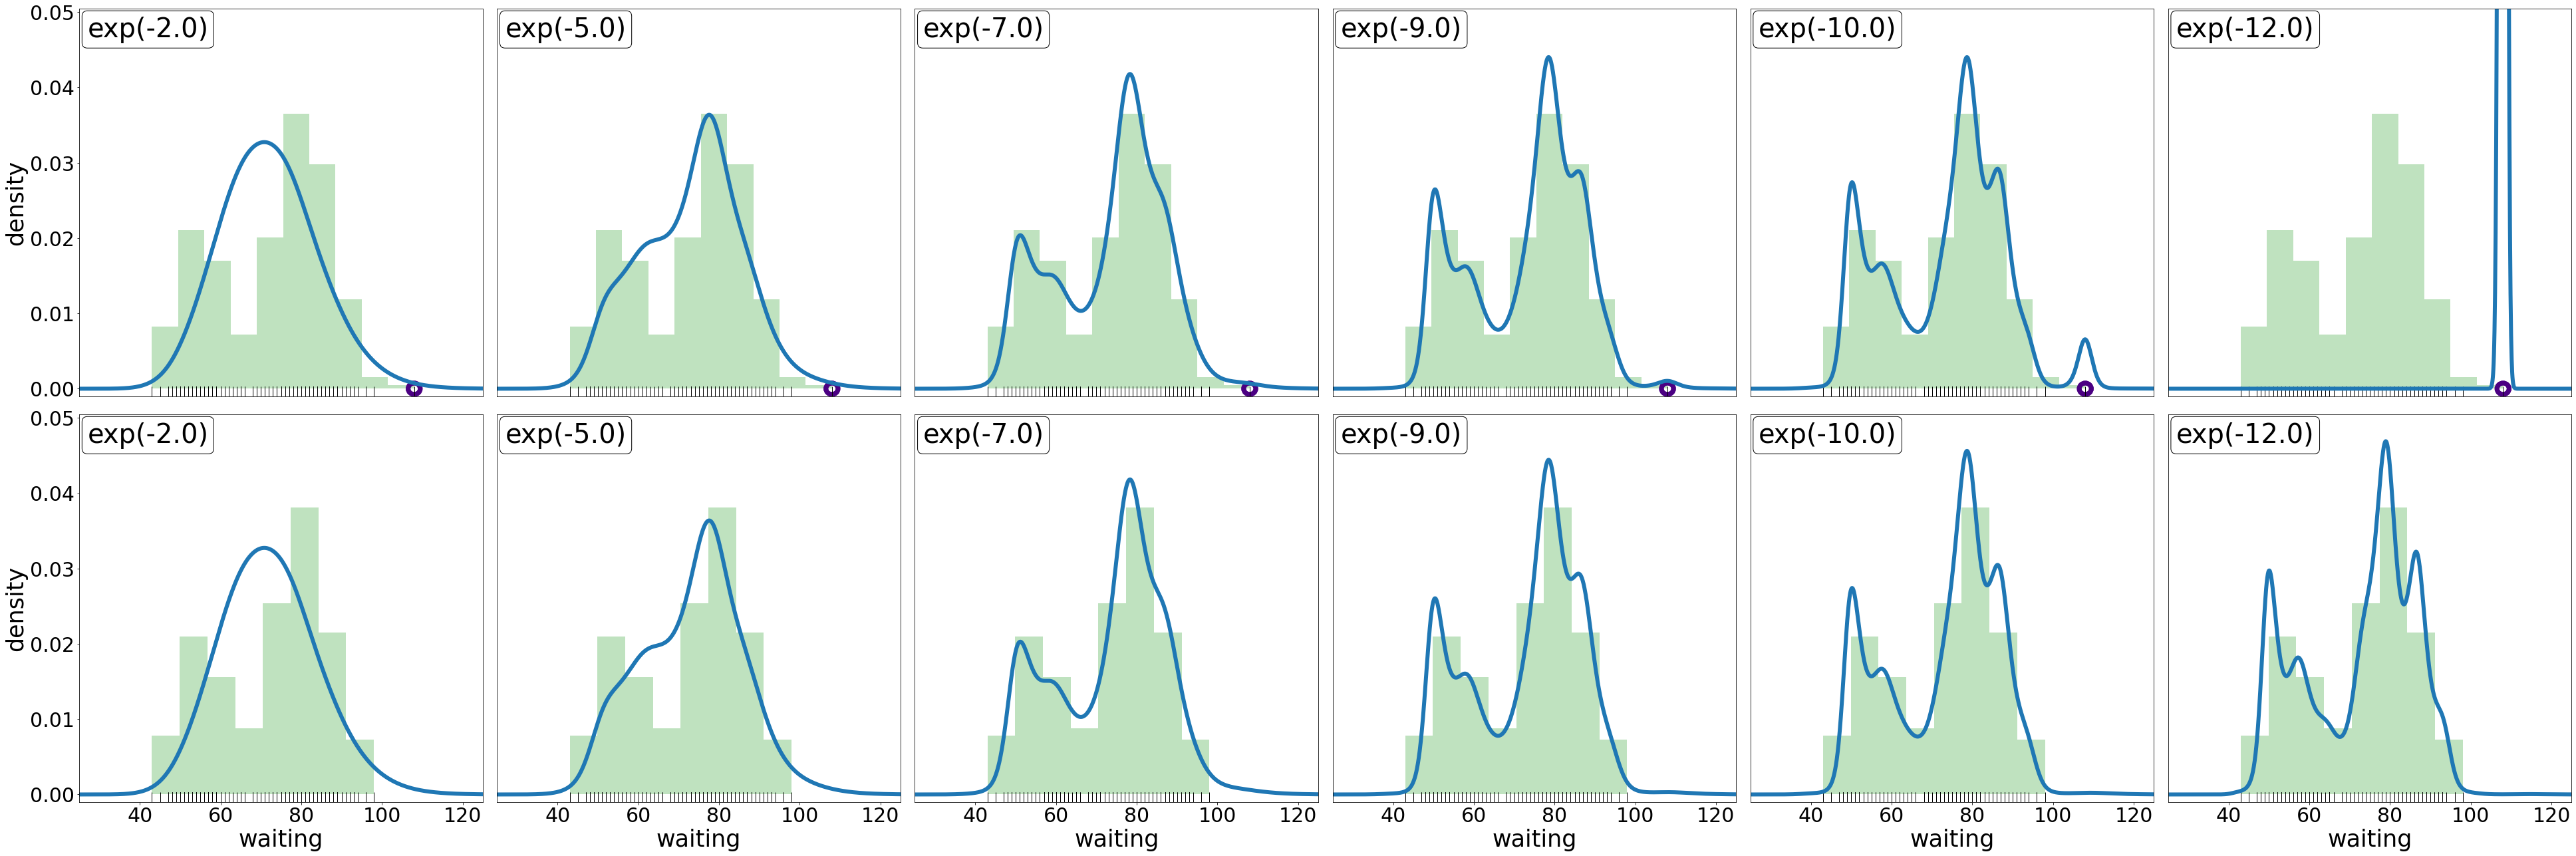

In [8]:
den_plot_xlim = (25., 125.) 
den_plot_ylim = (-0.001, 0.0505)
logden_plot_xlim = den_plot_xlim

info_coord = (0.02, 0.98)
horizontalalignment, verticalalignment = 'left', 'top'

label_fontsize = 35
info_fontsize = 40
tick_fontsize = 30
legend_fontsize = 25
linewidth = 6.0
x_label = r'waiting'
y_label = r'density'

nrows = 2
ncols = 6

fig = plt.figure(figsize=(54, 18))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

xticks = [40, 60, 80, 100, 120]

color1 = 'tab:red'
color2 = 'tab:blue'
color3 = 'tab:brown'

new_data = np.load(smpen_folder_t + f'/new_data.npy')

for i in range(len(smpen_list)): 
    
    ax1 = fig.add_subplot(gs[0, i])
    contam_den = np.load(smpen_folder_t + f'/logpenparam={smpen_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color2)

    sns.rugplot(pd.Series(waiting1.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    plt.hist(waiting1, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
                                         color = 'indigo', fill = False, linewidth = 7.0)))
    
    ax1.set_xticks([])
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])

    info = r"exp({ll})".format(ll = smpen_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})
    
for i in range(len(smpen_list)): 
    
    ax1 = fig.add_subplot(gs[1, i])
    contam_den = np.load(smpen_folder_f + f'/logpenparam={smpen_list[i]}-densityvals-newdata.npy')
    ax1.plot(new_data.flatten(), contam_den.flatten(), linewidth = linewidth, color = color2)

    sns.rugplot(pd.Series(waiting2.flatten()), ax = ax1, color = 'black')

    ax1.set_xlim(den_plot_xlim)
    ax1.set_ylim(den_plot_ylim)
    # ax1.set_xlabel(x_label, fontsize = label_fontsize)
    # ax1.set_ylabel(y_label, fontsize = label_fontsize)
    ax1.tick_params(axis = 'both', labelsize = tick_fontsize)
    
    if i == 0: 
        ax1.set_ylabel(y_label, fontsize = label_fontsize)
    else: 
        ax1.set_yticks([])
        
    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticks, size = tick_fontsize)
    
    plt.hist(waiting2, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    # ax1.add_patch(ax1.add_artist(Ellipse((contam_data, 0.), 3., 0.0015, 
    #                                      color = 'indigo', fill = False, linewidth = 7.0)))
    
    ax1.set_xlabel(x_label, fontsize = label_fontsize)

    info = r"exp({ll})".format(ll = smpen_list[i])
    ax1.text(*info_coord,
             info,
             fontsize = info_fontsize,
             multialignment = 'left',
             horizontalalignment = horizontalalignment, 
             verticalalignment = verticalalignment, 
             transform = ax1.transAxes,
             bbox = {'facecolor': 'none',
                     'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'../plots/waiting-PenSMonly-density-estimates-baseden=Gamma-{base_density.a}-{base_density.scale}-gridpoint=1-202-1-with108-brief.pdf', 
            bbox_inches = 'tight')
plt.show()
